# Os bairros de Uberlândia em dados (Censo 2022)

Primeiro projeto do meu portfólio de análise de dados. A ideia: responder com dados públicos perguntas simples sobre a cidade onde eu moro.

- Qual é o bairro mais populoso de Uberlândia?
- Onde a cidade está mais apertada (densidade)?
- Quais bairros têm mais gente jovem e quais têm mais idosos?
- Como fica a distribuição por cor ou raça?

**Fonte dos dados:** IBGE, Censo Demográfico 2022, agregados por bairros. O IBGE publicou os resultados já agregados por bairro oficial, o que é raro e facilita muito a vida: não preciso cruzar setores censitários com mapas da prefeitura.

Links oficiais:

- [Agregados por setores censitários (área de downloads do Censo 2022)](https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Setores_Censitarios/)
- [Página do Censo 2022](https://www.ibge.gov.br/estatisticas/sociais/populacao/22827-censo-demografico-2022.html)

O notebook baixa os arquivos direto do site do IBGE, então dá para rodar do zero sem baixar nada manualmente.

## 1. Setup

Bibliotecas: `pandas` para as tabelas, `geopandas` para os mapas, `matplotlib` para os gráficos.

In [1]:
import os
import zipfile
import urllib.request

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

os.makedirs('dados', exist_ok=True)
os.makedirs('graficos', exist_ok=True)

def baixar(url, destino):
    # baixa só se ainda não existe, para não repetir download a cada execução
    if not os.path.exists(destino):
        print(f'baixando {destino} ...')
        urllib.request.urlretrieve(url, destino)
    return destino

print('ok')

ok


## 2. Download dos arquivos do IBGE

Três arquivos CSV (básico, demografia e cor ou raça) e a malha geográfica dos bairros em formato GeoPackage.

In [2]:
FTP = 'https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Setores_Censitarios'

arquivos = {
    'basico': f'{FTP}/Agregados_por_Bairro_csv/Agregados_por_bairros_basico_BR_20260520.zip',
    'demografia': f'{FTP}/Agregados_por_Bairro_csv/Agregados_por_bairros_demografia_BR.zip',
    'raca': f'{FTP}/Agregados_por_Bairro_csv/Agregados_por_bairros_cor_ou_raca_BR.zip',
}

for nome, url in arquivos.items():
    zip_path = baixar(url, f'dados/{nome}.zip')
    with zipfile.ZipFile(zip_path) as z:
        z.extractall('dados')

malha_path = baixar(
    f'{FTP}/malha_com_atributos/bairros/gpkg/UF/MG/MG_bairros_CD2022.gpkg',
    'dados/MG_bairros_CD2022.gpkg',
)
print('arquivos prontos')

arquivos prontos


## 3. Carregar e filtrar Uberlândia

Os CSVs vêm com o Brasil inteiro, separador `;` e encoding latin-1 (padrão dos arquivos do IBGE). Filtro pelo código do município de Uberlândia: **3170206**.

In [3]:
def ler_agregado(padrao):
    df = pd.read_csv(padrao, sep=';', encoding='latin-1', dtype={'CD_BAIRRO': str, 'CD_MUN': str})
    # o IBGE marca valores suprimidos com '.', aqui viro 0 e converto tudo para número
    for col in df.columns:
        if not col.startswith(('CD_', 'NM_')):
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df

basico = ler_agregado('dados/Agregados_por_bairros_basico_BR.csv')
demo = ler_agregado('dados/Agregados_por_bairros_demografia_BR.csv')
raca = ler_agregado('dados/Agregados_por_bairros_cor_ou_raca_BR.csv')

COD_UDI = '3170206'
basico = basico[basico['CD_MUN'] == COD_UDI].copy()
demo = demo[demo['CD_BAIRRO'].isin(basico['CD_BAIRRO'])].copy()
raca = raca[raca['CD_BAIRRO'].isin(basico['CD_BAIRRO'])].copy()

print(f'bairros de Uberlândia no arquivo: {len(basico)}')
basico.head(3)

bairros de Uberlândia no arquivo: 75


,CD_BAIRRO,NM_BAIRRO,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_MUN,NM_MUN,CD_DIST,NM_DIST,...,AREA_KM2,v0001,v0002,v0003,v0004,v0005,v0006,v0007,v0008,v0009
7123,3170206001,Tibery,3,Sudeste,31,Minas Gerais,3170206,Uberlândia,317020605,Uberlândia,...,0.0,15213.0,7312.0,7303.0,9.0,0.0,0.0,5926.0,258.0,1119.0
7124,3170206002,Brasil,3,Sudeste,31,Minas Gerais,3170206,Uberlândia,317020605,Uberlândia,...,0.0,10442.0,5220.0,5210.0,10.0,0.0,0.0,4213.0,158.0,839.0
7125,3170206003,Marta Helena,3,Sudeste,31,Minas Gerais,3170206,Uberlândia,317020605,Uberlândia,...,0.0,7639.0,3805.0,3800.0,5.0,0.0,0.0,2992.0,126.0,682.0


### Conferência rápida

Comparo a soma dos bairros com o total oficial do município publicado pelo IBGE: **713.224** pessoas no Censo 2022.

In [4]:
total_bairros = int(basico['v0001'].sum())
oficial = 713_224
print(f'população dentro dos bairros oficiais: {total_bairros:,.0f}'.replace(',', '.'))
print(f'população total do município:          {oficial:,.0f}'.replace(',', '.'))
print(f'fora dos limites de bairro:            {oficial - total_bairros:,.0f}'.replace(',', '.'))

população dentro dos bairros oficiais: 680.318
população total do município:          713.224
fora dos limites de bairro:            32.906


A soma dos bairros dá menos que o total do município, e isso é esperado: o agregado por bairros cobre só os bairros oficiais da área urbana. Quem mora na zona rural ou em áreas sem bairro oficial delimitado fica de fora desses arquivos. Para análise por bairro, trabalho com as 680 mil pessoas dentro dos limites oficiais.

## 4. Montar a tabela de análise

Junto as três fontes em uma tabela só, com nomes de coluna legíveis. Uso:

- `v0001`: total de pessoas
- `v0002`: total de domicílios
- `v0005`: média de moradores por domicílio
- `V01031` a `V01041`: pessoas por faixa etária
- `V01317` a `V01321`: pessoas por cor ou raça

In [5]:
bairros = basico[['CD_BAIRRO', 'NM_BAIRRO', 'AREA_KM2', 'v0001', 'v0002', 'v0005']].copy()
bairros.columns = ['cd_bairro', 'bairro', 'area_km2', 'pessoas', 'domicilios', 'moradores_por_domicilio']

faixas = {
    'V01031': '0-4', 'V01032': '5-9', 'V01033': '10-14', 'V01034': '15-19',
    'V01035': '20-24', 'V01036': '25-29', 'V01037': '30-39', 'V01038': '40-49',
    'V01039': '50-59', 'V01040': '60-69', 'V01041': '70+',
}
demo_sel = demo[['CD_BAIRRO'] + list(faixas)].rename(columns={'CD_BAIRRO': 'cd_bairro', **faixas})
bairros = bairros.merge(demo_sel, on='cd_bairro')

cor = {
    'V01317': 'branca', 'V01318': 'preta', 'V01319': 'amarela',
    'V01320': 'parda', 'V01321': 'indigena',
}
raca_sel = raca[['CD_BAIRRO'] + list(cor)].rename(columns={'CD_BAIRRO': 'cd_bairro', **cor})
bairros = bairros.merge(raca_sel, on='cd_bairro')

bairros['densidade'] = bairros['pessoas'] / bairros['area_km2']
bairros.head()

,cd_bairro,bairro,area_km2,pessoas,domicilios,moradores_por_domicilio,0-4,5-9,10-14,15-19,...,40-49,50-59,60-69,70+,branca,preta,amarela,parda,indigena,densidade
0,3170206001,Tibery,0.0,15213.0,7312.0,0.0,772.0,793.0,849.0,898.0,...,2125.0,1956.0,1688.0,1465.0,7972.0,1704.0,6.0,5495.0,12.0,inf
1,3170206002,Brasil,0.0,10442.0,5220.0,0.0,473.0,491.0,527.0,538.0,...,1506.0,1391.0,1180.0,1273.0,6655.0,716.0,29.0,3006.0,4.0,inf
2,3170206003,Marta Helena,0.0,7639.0,3805.0,0.0,395.0,469.0,423.0,476.0,...,1077.0,1001.0,768.0,724.0,3795.0,723.0,7.0,3104.0,0.0,inf
3,3170206004,Bom Jesus,0.0,3161.0,1815.0,0.0,121.0,144.0,181.0,196.0,...,426.0,412.0,376.0,437.0,1687.0,314.0,0.0,1149.0,0.0,inf
4,3170206005,Umuarama,0.0,3623.0,2819.0,0.0,133.0,132.0,130.0,147.0,...,496.0,391.0,423.0,358.0,2410.0,233.0,28.0,936.0,4.0,inf


## 5. Os bairros mais populosos

Primeira pergunta: onde mora mais gente?

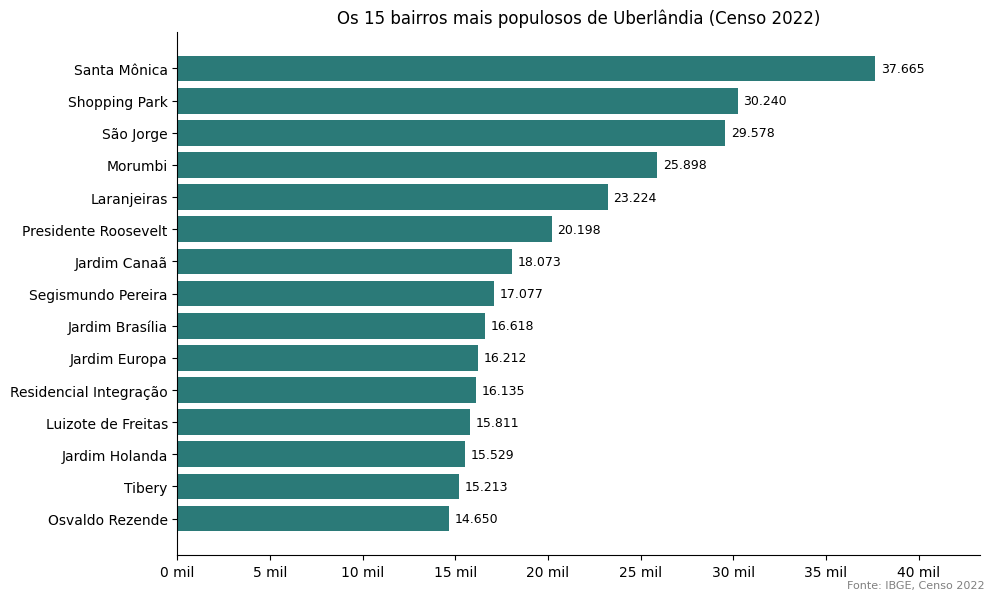

Campeão: Santa Mônica, com 37.665 moradores


In [6]:
top15 = bairros.nlargest(15, 'pessoas').sort_values('pessoas')

fig, ax = plt.subplots()
ax.barh(top15['bairro'], top15['pessoas'], color='#2b7a78')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f} mil'))
ax.set_title('Os 15 bairros mais populosos de Uberlândia (Censo 2022)')
for i, v in enumerate(top15['pessoas']):
    ax.text(v + 300, i, f'{v:,.0f}'.replace(',', '.'), va='center', fontsize=9)
ax.set_xlim(0, top15['pessoas'].max() * 1.15)
fig.text(0.99, 0.01, 'Fonte: IBGE, Censo 2022', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/top15_bairros_populacao.png', dpi=150, bbox_inches='tight')
plt.show()

n1 = bairros.nlargest(1, 'pessoas').iloc[0]
print(f"Campeão: {n1['bairro']}, com " + f"{n1['pessoas']:,.0f}".replace(',', '.') + " moradores")

## 6. Mapa da população por bairro

A tabela responde "quanto", o mapa mostra "onde". Cruzamento dos dados com a malha geográfica oficial dos bairros.

bairros no mapa: 75


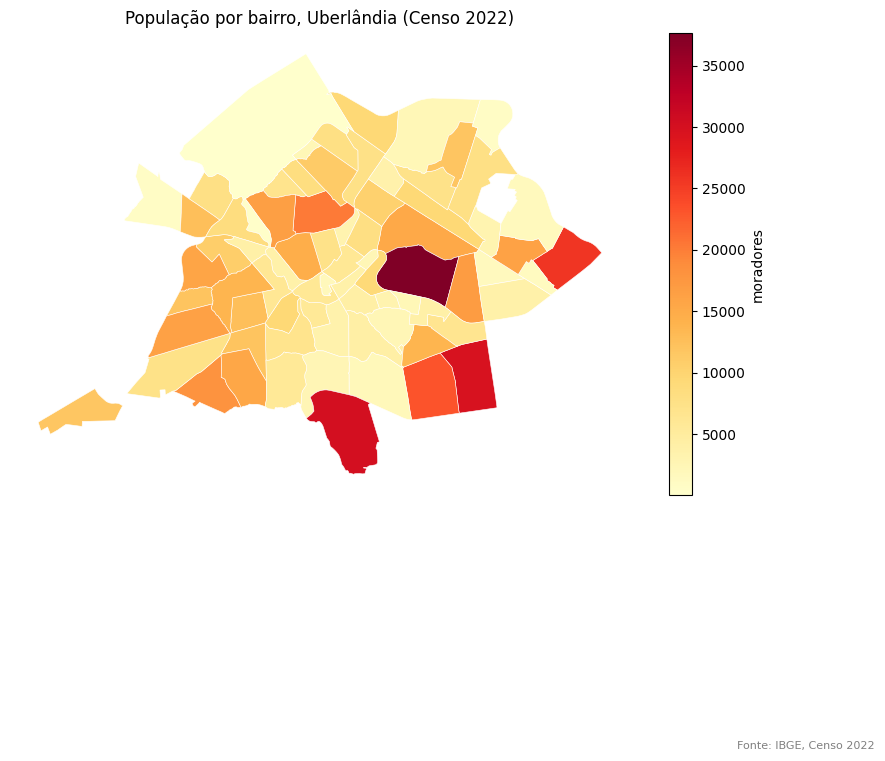

In [7]:
malha = gpd.read_file('dados/MG_bairros_CD2022.gpkg')
mapa = malha[malha['CD_MUN'] == COD_UDI].merge(
    bairros, left_on='CD_BAIRRO', right_on='cd_bairro'
)
print(f'bairros no mapa: {len(mapa)}')

fig, ax = plt.subplots(figsize=(10, 10))
mapa.plot(column='pessoas', cmap='YlOrRd', legend=True, ax=ax, edgecolor='white', linewidth=0.4,
          legend_kwds={'label': 'moradores', 'shrink': 0.6})
ax.set_title('População por bairro, Uberlândia (Censo 2022)')
ax.axis('off')
fig.text(0.99, 0.01, 'Fonte: IBGE, Censo 2022', ha='right', fontsize=8, color='gray')
plt.savefig('graficos/mapa_populacao_bairros.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Densidade: onde a cidade aperta

População dividida pela área do bairro (hab/km²). Bairro grande em área nem sempre é bairro cheio.

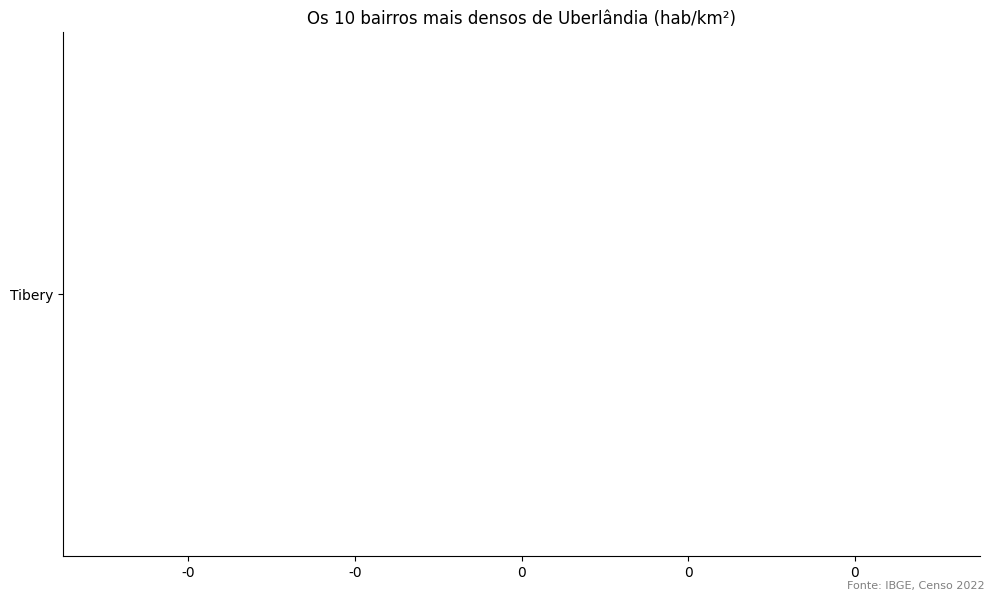

In [8]:
top_dens = bairros.nlargest(10, 'densidade').sort_values('densidade')

fig, ax = plt.subplots()
ax.barh(top_dens['bairro'], top_dens['densidade'], color='#c94c4c')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
ax.set_title('Os 10 bairros mais densos de Uberlândia (hab/km²)')
fig.text(0.99, 0.01, 'Fonte: IBGE, Censo 2022', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/top10_densidade.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Juventude e terceira idade

Comparo a fatia de até 19 anos com a de 60 anos ou mais em cada bairro. Serve para ver onde a cidade é mais jovem e onde está envelhecendo.

In [9]:
bairros['pct_ate19'] = (bairros[['0-4','5-9','10-14','15-19']].sum(axis=1) / bairros['pessoas']) * 100
bairros['pct_60mais'] = (bairros[['60-69','70+']].sum(axis=1) / bairros['pessoas']) * 100

jovens = bairros.nlargest(5, 'pct_ate19')[['bairro', 'pct_ate19']]
idosos = bairros.nlargest(5, 'pct_60mais')[['bairro', 'pct_60mais']]

print('Bairros com mais gente até 19 anos (%):')
print(jovens.to_string(index=False, formatters={'pct_ate19': '{:.1f}%'.format}))
print()
print('Bairros com mais gente de 60+ (%):')
print(idosos.to_string(index=False, formatters={'pct_60mais': '{:.1f}%'.format}))

Bairros com mais gente até 19 anos (%):
                bairro pct_ate19
                Pequis     40.4%
            Jardim Sul     35.0%
        Portal do Vale     33.6%
Residencial Integração     31.5%
      Granja Marileusa     31.0%

Bairros com mais gente de 60+ (%):
       bairro pct_60mais
     Fundinho      38.6%
       Centro      29.7%
Morada do Sol      29.2%
    Tabajaras      28.3%
       Lídice      28.0%


## 9. Pirâmide etária da cidade

Somando todos os bairros, a cara da população de Uberlândia em 2022:

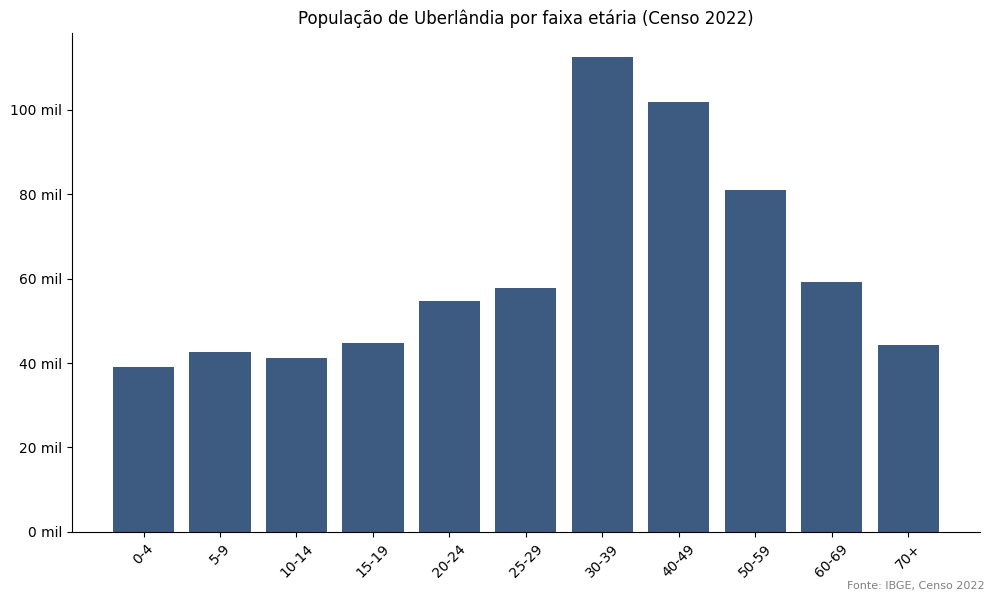

In [10]:
totais = bairros[list(faixas.values())].sum()

fig, ax = plt.subplots()
ax.bar(totais.index, totais.values, color='#3d5a80')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f} mil'))
ax.set_title('População de Uberlândia por faixa etária (Censo 2022)')
plt.xticks(rotation=45)
fig.text(0.99, 0.01, 'Fonte: IBGE, Censo 2022', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/piramide_etaria.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Cor ou raça

Distribuição na cidade inteira e um mapa da proporção de pessoas brancas por bairro, para ver como a composição varia dentro da cidade.

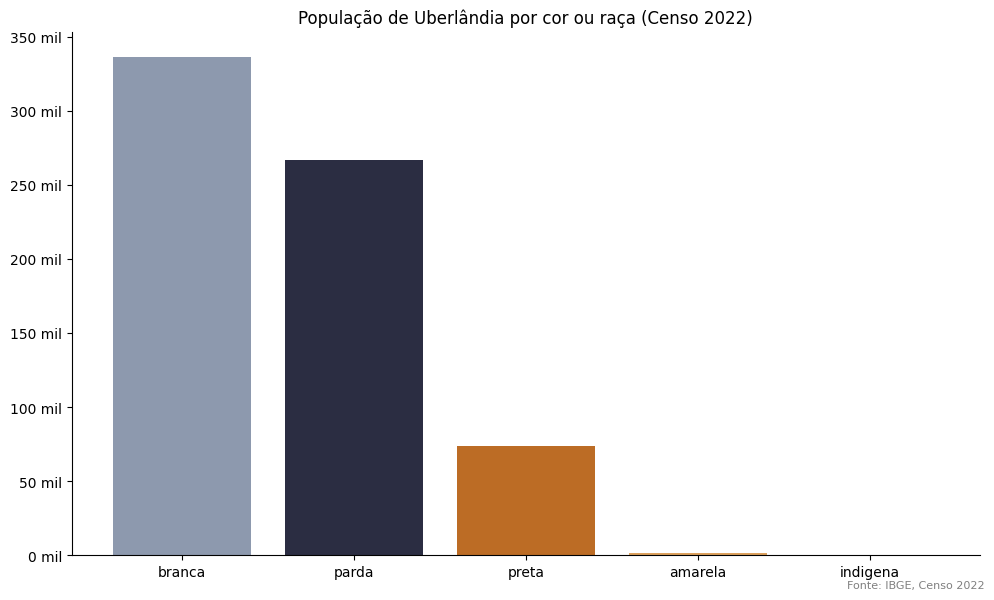

branca: 49.4%
parda: 39.2%
preta: 10.8%
amarela: 0.2%
indigena: 0.0%


In [11]:
categorias = ['branca', 'preta', 'parda', 'amarela', 'indigena']
tot_cor = bairros[categorias].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
ax.bar(tot_cor.index, tot_cor.values, color=['#8d99ae', '#2b2d42', '#bc6c25', '#dda15e', '#606c38'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f} mil'))
ax.set_title('População de Uberlândia por cor ou raça (Censo 2022)')
fig.text(0.99, 0.01, 'Fonte: IBGE, Censo 2022', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/cor_raca_cidade.png', dpi=150, bbox_inches='tight')
plt.show()

for cat, v in tot_cor.items():
    print(f'{cat}: {v / bairros["pessoas"].sum() * 100:.1f}%')

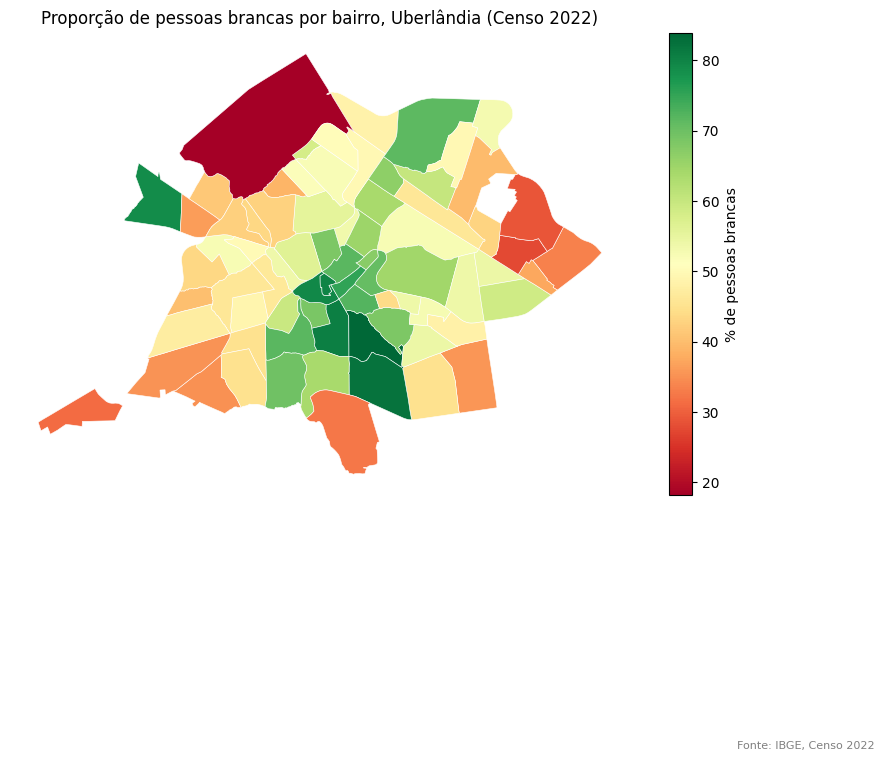

In [12]:
mapa['pct_branca'] = (mapa['branca'] / mapa['pessoas']) * 100

fig, ax = plt.subplots(figsize=(10, 10))
mapa.plot(column='pct_branca', cmap='RdYlGn', legend=True, ax=ax, edgecolor='white', linewidth=0.4,
          legend_kwds={'label': '% de pessoas brancas', 'shrink': 0.6})
ax.set_title('Proporção de pessoas brancas por bairro, Uberlândia (Censo 2022)')
ax.axis('off')
fig.text(0.99, 0.01, 'Fonte: IBGE, Censo 2022', ha='right', fontsize=8, color='gray')
plt.savefig('graficos/mapa_pct_branca.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. O que eu tiro disso

Números que saíram da análise (Censo 2022, bairros oficiais de Uberlândia):

- **Santa Mônica** é o bairro mais populoso: 37.665 moradores, mais que muita cidade do interior.
- O pódio fecha com **Shopping Park** (30.240) e **São Jorge** (29.578). No mapa dá para ver o peso da região central e da zona sul, com o extremo norte bem mais vazio.
- **Pequis** é o bairro com mais gente jovem: 40,4% dos moradores têm até 19 anos.
- **Fundinho** é o mais envelhecido: 38,6% têm 60 anos ou mais. Centro (29,7%) vem logo atrás, o que mostra o envelhecimento da região central.
- Na cidade como um todo: 49,4% se declaram brancos, 39,2% pardos, 10,8% pretos. O mapa por bairro mostra que essa composição muda bastante de uma região para outra.

Próximos passos possíveis: cruzar com dados de renda quando o IBGE detalhar a amostra em áreas menores, e comparar com o Censo 2010 para ver quais bairros mais cresceram.